# PEPE Hourly Factor Research Regression

This notebook tests how PEPE hourly returns move with contemporaneous crypto market factors, BTC volatility/risk proxies, hourly ETF market proxies, and slow macro variables aligned to the Binance hourly timeline. It is an explanatory research regression, so some predictors are same-hour factors rather than tradeable signals. Use the trading forecast notebook for strictly lagged, backtest-oriented signals.


## Setup and hourly data configuration


In [13]:
from pathlib import Path
import sys

import pandas as pd

# Setup
project_root = next(
    path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (path / "refresh_data.py").exists() and (path / "data").exists()
)
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from features import build_research_features
from load_data import load_market_data
from modeling import fit_regression_models
from plots import plot_correlation_matrix, plot_cumulative_returns, plot_regression_fit

time_interval = "1H"
coin_order = ["PEPE", "BTC", "ETH", "SOL", "BNB", "XRP", "DOGE", "SHIB"]
target = "PEPE"
peer_coins = [coin for coin in coin_order if coin != target]
coin_colors = {
    "PEPE": "green",
    "BTC": "orange",
    "ETH": "grey",
    "SOL": "purple",
    "BNB": "gold",
    "XRP": "navy",
    "DOGE": "red",
    "SHIB": "brown",
}


## Load Binance hourly crypto data


In [14]:
# Load downloaded market data
market_data = load_market_data(project_root, time_interval, coin_order)

open_prices = market_data["open_prices"]
high_prices = market_data["high_prices"]
low_prices = market_data["low_prices"]
close_prices = market_data["close_prices"]
volume_from = market_data["volume_from"]
raw_returns = market_data["raw_returns"]
log_returns = market_data["log_returns"]
fred_features = market_data["fred_features"]
yfinance_log_returns = market_data["yfinance_log_returns"]
btc_funding = market_data["btc_funding"]
btc_dvol = market_data["btc_dvol"]
cumulative_returns = market_data["cumulative_returns"]
simple_cumulative_returns = market_data["simple_cumulative_returns"]


## Build hourly (log) returns and aligned external factors


In [15]:
print("Simple cumulative return:")
with pd.option_context("display.max_columns", None, "display.width", 200):
    print(simple_cumulative_returns.tail())
print()


Simple cumulative return:
coin                           PEPE       BTC       ETH       SOL       BNB       XRP      DOGE      SHIB
timestamp                                                                                                
2026-07-29 04:00:00+00:00 -0.737799 -0.014325 -0.403479 -0.560232 -0.011009  0.835258 -0.402692 -0.708386
2026-07-29 05:00:00+00:00 -0.735885 -0.012800 -0.401282 -0.558855 -0.009148  0.844090 -0.402184 -0.705845
2026-07-29 06:00:00+00:00 -0.734928 -0.007125 -0.398890 -0.556460 -0.006557  0.847317 -0.400660 -0.706480
2026-07-29 07:00:00+00:00 -0.735885 -0.005193 -0.397472 -0.555383 -0.005391  0.851732 -0.399052 -0.705845
2026-07-29 08:00:00+00:00 -0.737799 -0.007982 -0.400374 -0.557538 -0.007757  0.844939 -0.402692 -0.707751



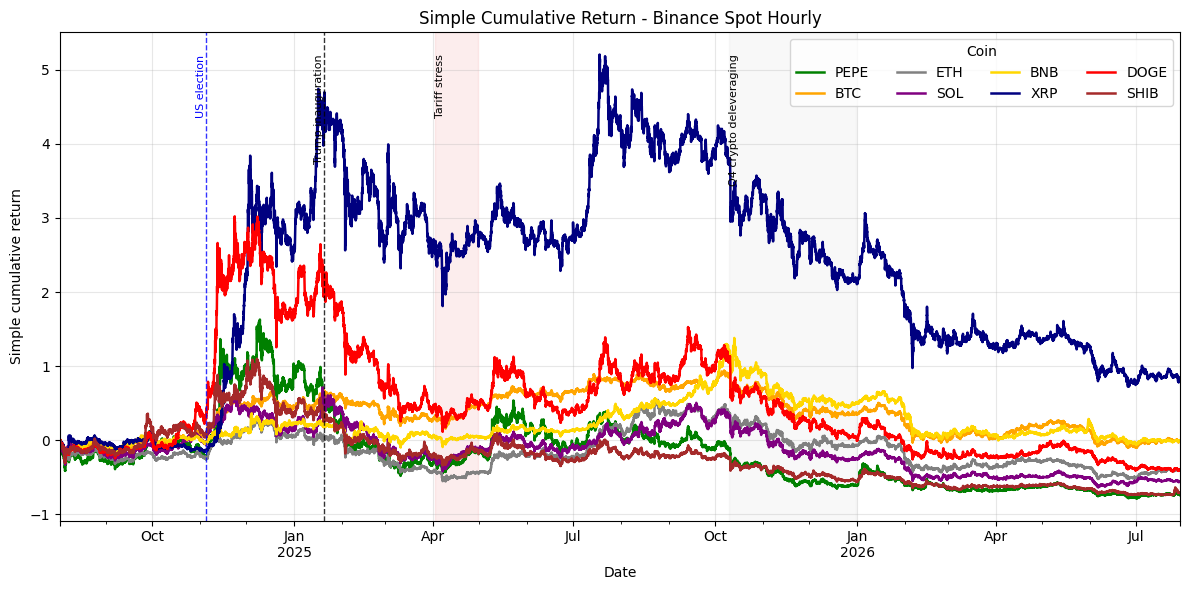

In [16]:
plot_cumulative_returns(
    simple_cumulative_returns,
    coin_colors,
    title="Simple Cumulative Return - Binance Spot Hourly",
    ylabel="Simple cumulative return",
    ncols=4,
)


## Build explanatory feature matrix


In [17]:
# Build same-hour feature matrix for explanatory fit testing
# - target PEPE is the current hourly log return
# - broad market returns are same-hour features
# - PEPE/BTC technical factors are same-hour descriptive features
# - this matrix explains co-movement and market state, not tradable forecasts
features, model_data = build_research_features(target, peer_coins, market_data)

print(f"Number of model features: {features.shape[1]}")
print()
print("Model data:")
with pd.option_context(
    "display.max_columns", None,
    "display.width", None,
    "display.expand_frame_repr", False,
):
    print(model_data.head(10))

print()
print("Dependent Variable is current-hour PEPE log return.")
print("Predictors are same-hour explanatory features, including crypto returns, market proxies, macro context, funding, DVOL, and PEPE/BTC technical state.")
print("This research matrix explains co-movement and market state. It is not a tradable forecast matrix.")

print("Predictors use Binance spot hourly OHLCV plus hourly yfinance ETF proxies.")
print("FRED macro series are lower frequency and forward-filled onto hourly timestamps.")


Number of model features: 31

Model data:
                               PEPE       BTC       ETH       SOL       BNB       XRP      DOGE      SHIB  PEPE_momentum_7h  PEPE_momentum_14h  PEPE_volatility_7h  PEPE_volatility_14h  PEPE_volume_change  PEPE_range  BTC_volatility_14h  BTC_range  BTC_funding_rate_sum  BTC_DVOL_change  M2_30d_change  SOFR_change  DFF_change  QQQ  SPY  IEF  TLT  UUP  HYG  VXX  PEPE_SMA12h   PEPE_SMA26h  PEPE_RSI_14h  PEPE_BB_percent_b_20h
timestamp                                                                                                                                                                                                                                                                                                                                                                                                                               
2024-10-01 00:00:00+00:00  0.014238  0.003222  0.006355  0.010957  0.007900  0.014291  0.013394  0.036876   

In [18]:
print(features.isna().sum().sort_values(ascending=False).to_string())


M2_30d_change            1440
PEPE_SMA26h                25
PEPE_BB_percent_b_20h      19
IEF                        14
SPY                        14
TLT                        14
UUP                        14
QQQ                        14
PEPE_RSI_14h               14
HYG                        14
VXX                        14
PEPE_volatility_14h        13
BTC_volatility_14h         13
PEPE_momentum_14h          13
PEPE_SMA12h                11
PEPE_volatility_7h          6
PEPE_momentum_7h            6
SOFR_change                 1
PEPE_volume_change          1
BTC_DVOL_change             1
DFF_change                  1
BTC_range                   0
SHIB                        0
BTC                         0
PEPE_range                  0
ETH                         0
SOL                         0
BNB                         0
XRP                         0
DOGE                        0
BTC_funding_rate_sum        0


## Feature correlation diagnostics


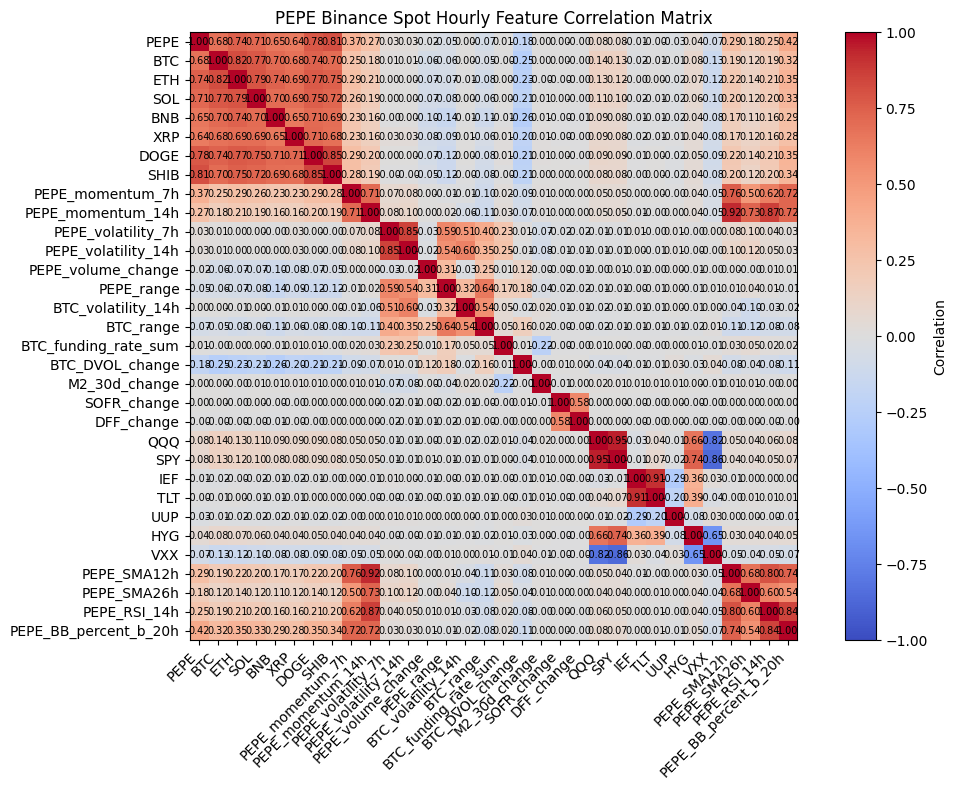

In [19]:
plot_correlation_matrix(model_data, "PEPE Binance Spot Hourly Feature Correlation Matrix")


## Fit explanatory regression models


In [20]:
# Linear, Ridge, and ElasticNet regression
feature_columns = list(features.columns)
model_result = fit_regression_models(model_data, target, feature_columns)

feature_columns = model_result["feature_columns"]
train_data = model_result["train_data"]
test_data = model_result["test_data"]
X_train = model_result["X_train"]
X_test = model_result["X_test"]
y_train = model_result["y_train"]
y_test = model_result["y_test"]
model = model_result["model"]
y_pred = model_result["y_pred"]
ridge_model = model_result["ridge_model"]
ridge_y_pred = model_result["ridge_y_pred"]
elastic_net_model = model_result["elastic_net_model"]
elastic_net_y_pred = model_result["elastic_net_y_pred"]
model_accuracy_comparison = model_result["model_accuracy_comparison"]
model_comparison = model_result["model_comparison"]
elastic_net_coefficients = model_result["elastic_net_coefficients"]
elastic_net_selected_coefficients = model_result["elastic_net_selected_coefficients"]
metrics_by_model = model_accuracy_comparison.set_index("model")

print()
print(model.summary())



                            OLS Regression Results                            
Dep. Variable:                   PEPE   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.740
Method:                 Least Squares   F-statistic:                     1179.
Date:                Wed, 29 Jul 2026   Prob (F-statistic):               0.00
Time:                        18:29:21   Log-Likelihood:                 46107.
No. Observations:               12794   AIC:                        -9.215e+04
Df Residuals:                   12762   BIC:                        -9.191e+04
Df Model:                          31                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     0.0

### Model comparison and ElasticNet coefficients

Elastic Net coefficients are shown directly below the model comparison so the selected features are easy to inspect.


In [21]:
print("Model comparison")
print(model_comparison.to_string(index=False, float_format=lambda value: f"{value:.6f}"))

print()
print("ElasticNet selected coefficients")
print(elastic_net_selected_coefficients.to_string(index=False, float_format=lambda value: f"{value:.6g}"))


Model comparison
     model       alpha  l1_ratio  nonzero_coefficients  train_r2  adjusted_train_r2  test_r2  adjusted_test_r2     rmse  prediction_correlation  cv_r2_mean
       OLS         NaN       NaN                    31  0.741122           0.740493 0.695073          0.692089 0.004526                0.838587    0.743213
     Ridge 1000.000000       NaN                    31  0.737719           0.737082 0.709846          0.707006 0.004415                0.844807    0.751488
ElasticNet    0.010000  0.100000                     6  0.721303           0.720626 0.697541          0.694581 0.004508                0.835412    0.771168

ElasticNet selected coefficients
              feature  coefficient  abs_coefficient
                 SHIB   0.00529895       0.00529895
                  ETH   0.00213136       0.00213136
                 DOGE   0.00182448       0.00182448
                  SOL  0.000972858      0.000972858
     PEPE_momentum_7h  0.000576316      0.000576316
PEPE_BB_perce

## Model comparison and diagnostics


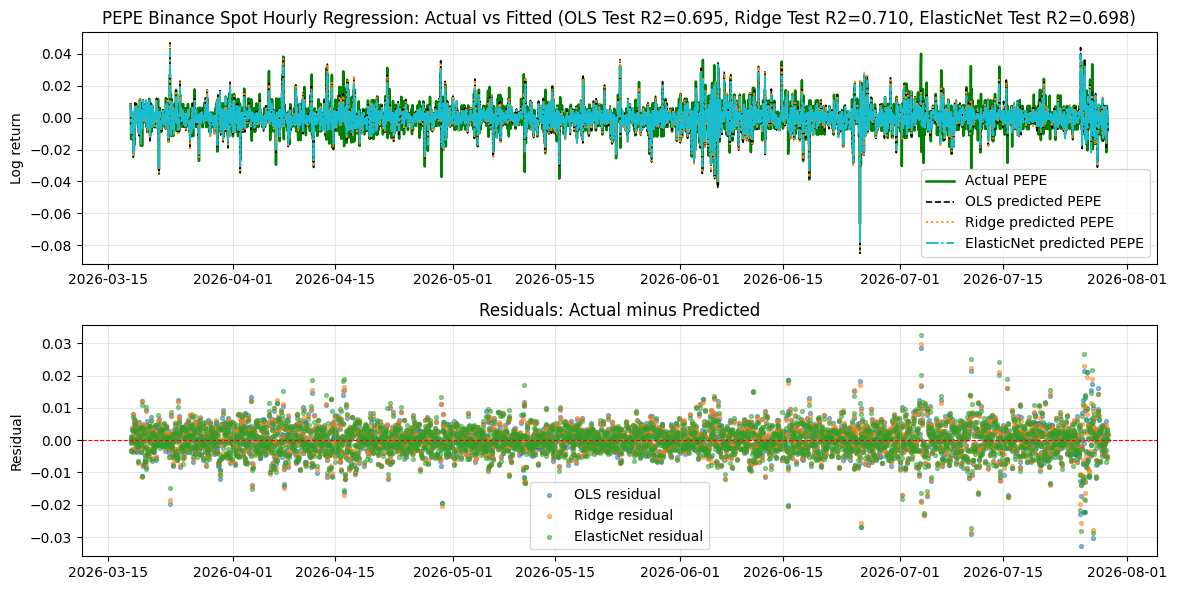

In [22]:
predictions = {
    "OLS": y_pred,
    "Ridge": ridge_y_pred,
    "ElasticNet": elastic_net_y_pred,
}
plot_regression_fit(
    test_data,
    y_test,
    predictions,
    target=target,
    target_color=coin_colors[target],
    title=(
        f"PEPE Binance Spot Hourly Regression: Actual vs Fitted "
        f"(OLS Test R2={metrics_by_model.loc['OLS', 'test_r2']:.3f}, "
        f"Ridge Test R2={metrics_by_model.loc['Ridge', 'test_r2']:.3f}, "
        f"ElasticNet Test R2={metrics_by_model.loc['ElasticNet', 'test_r2']:.3f})"
    ),
)


## Notebook-only outputs

This notebook displays tables, summaries, and charts inline. It does not save research CSV, TXT, or PNG output files.